In [3]:
#Student Marks Prediction

##1. Business Problem

#A school wants to understand the relationship between students' study hours and their academic performance.

#The goal of this project is to build a Machine Learning model that can predict a student's marks based on the number of hours they study.

### Objective

#Analyze the relationship between study hours and marks.
#Build a Linear Regression model.
#Evaluate how well the model predicts student marks.
#Use the trained model to predict marks for a new student.


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
students = pd.DataFrame({
    "Study_Hours": [1, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6,
                    6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10],

    "Marks": [35, 42, 48, 50, 55, 60, 64, 68, 72, 75,
              78, 81, 84, 87, 89, 91, 93, 95]
})

students

,Study_Hours,Marks
0,1.0,35
1,2.0,42
2,2.5,48
3,3.0,50
4,3.5,55
5,4.0,60
6,4.5,64
7,5.0,68
8,5.5,72
9,6.0,75


In [6]:
print("First 5 rows:")
print(students.head())

print("\nDataset Shape:")
print(students.shape)

print("\nDataset Information:")
students.info()

print("\nStatistical Summary:")
print(students.describe())

First 5 rows:
   Study_Hours  Marks
0          1.0     35
1          2.0     42
2          2.5     48
3          3.0     50
4          3.5     55

Dataset Shape:
(18, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study_Hours  18 non-null     float64
 1   Marks        18 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 420.0 bytes

Statistical Summary:
       Study_Hours      Marks
count    18.000000  18.000000
mean      5.722222  70.388889
std       2.718251  18.645734
min       1.000000  35.000000
25%       3.625000  56.250000
50%       5.750000  73.500000
75%       7.875000  86.250000
max      10.000000  95.000000


In [7]:
print("Missing values:")
print(students.isna().sum())

print("\nDuplicate rows:")
print(students.duplicated().sum())

Missing values:
Study_Hours    0
Marks          0
dtype: int64

Duplicate rows:
0


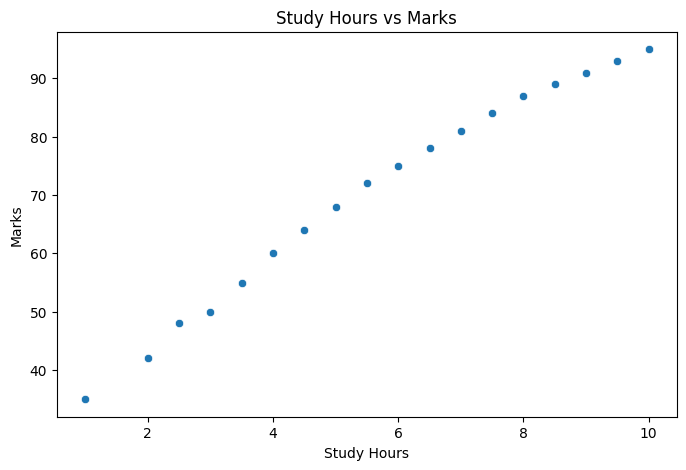

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Study_Hours",
    y="Marks",
    data=students
)

plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")

plt.show()


In [9]:
correlation = students["Study_Hours"].corr(students["Marks"])

print("Correlation between Study Hours and Marks:", correlation)

Correlation between Study Hours and Marks: 0.9916669863178319


In [10]:
X = students[["Study_Hours"]]
y = students["Marks"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (18, 1)
y shape: (18,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14, 1)
X_test shape: (4, 1)
y_train shape: (14,)
y_test shape: (4,)


In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [13]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 33.6745293717396
Coefficient: 6.481288273985034


In [14]:
y_pred = model.predict(X_test)

print("Actual Marks:")
print(y_test.values)

print("\nPredicted Marks:")
print(y_pred)

Actual Marks:
[35 42 72 60]

Predicted Marks:
[40.15581765 46.63710592 69.32161488 59.59968247]


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 3.21790655477432
MSE: 13.854801972871254
R² Score: 0.9350111898076986


In [16]:
new_student = pd.DataFrame({
    "Study_Hours": [7]
})

predicted_marks = model.predict(new_student)

print("Predicted Marks:", predicted_marks[0])

Predicted Marks: 79.04354728963483


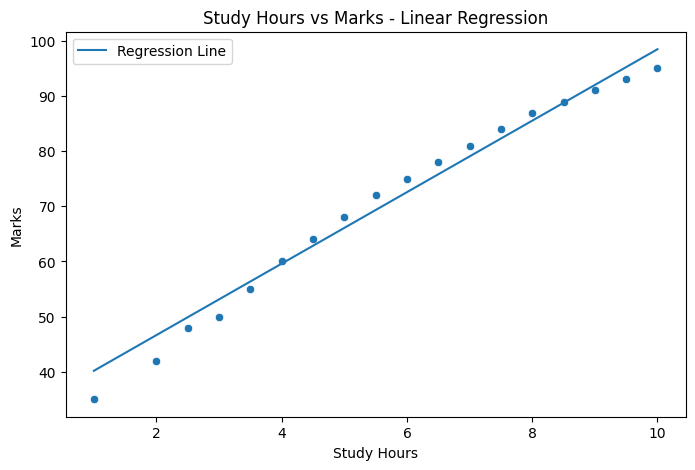

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Study_Hours",
    y="Marks",
    data=students
)

plt.plot(
    students["Study_Hours"],
    model.predict(X),
    label="Regression Line"
)

plt.title("Study Hours vs Marks - Linear Regression")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.legend()

plt.show()

In [18]:
print("===== Student Marks Prediction =====")
print("Correlation:", correlation)
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)
print("Prediction for 7 study hours:", predicted_marks[0])

===== Student Marks Prediction =====
Correlation: 0.9916669863178319
MAE: 3.21790655477432
MSE: 13.854801972871254
R² Score: 0.9350111898076986
Prediction for 7 study hours: 79.04354728963483


In [ ]:
### Business Conclusion

#The analysis shows a strong positive relationship between study hours and student marks, with a correlation of **0.992**.

#A Linear Regression model was trained using **80% of the data** and evaluated on the remaining **20% as unseen test data**.

#The model achieved the following results:

## * **MAE:** 3.22 marks
## * **MSE:** 13.85
## * **R² Score:** 0.935

#The R² score of **0.935** indicates that the model explains approximately **93.5% of the variation in student marks** within this dataset. The MAE of **3.22** means that the model's predictions were off by approximately 3.22 marks on average.

#For a new student studying **7 hours**, the model predicted approximately **79.04 marks**.

#Overall, the results suggest that study hours have a strong linear relationship with marks in this dataset, and Linear Regression can provide useful predictions for this problem.

#However, this is a small educational dataset, so the results should not be generalized to all students. In a real-world situation, other factors such as attendance, previous academic performance, study methods, and teaching quality could also affect student marks.
